In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from mintpy.utils import readfile
import pandas as pd
from datetime import datetime
import datetime

 Generated 443 grid-based points at 400m spacing.


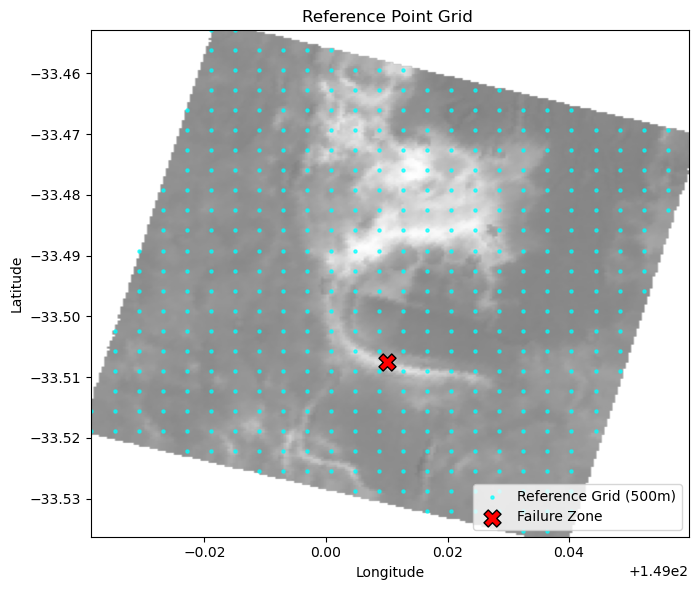

In [2]:
COH_THRESHOLD = 0.0
GEO_SCOH_FILE = 'geo/geo_avgSpatialCoh.h5'  # Background/Coherence Map
h5_path = 'geo/geo_timeseries_ERA5_demErr.h5'
DAM_LAT, DAM_LON = -33.5075, 149.0100
s_data, attr = readfile.read(GEO_SCOH_FILE, datasetName='coherence')
rows, cols = s_data.shape
lat0, lon0 = float(attr['Y_FIRST']), float(attr['X_FIRST'])
lat_step, lon_step = float(attr['Y_STEP']), float(attr['X_STEP'])
extent = [lon0, lon0 + cols * lon_step, lat0 + rows * lat_step, lat0]
dam_y = int((DAM_LAT - lat0) / lat_step)
dam_x = int((DAM_LON - lon0) / lon_step)

meters_per_lat_px = abs(lat_step) * 111111
meters_per_lon_px = abs(lon_step) * 111111 * np.cos(np.radians(lat0))
step_y = max(1, int(400 / meters_per_lat_px)) # Calculate pixel steps for 400m spacing
step_x = max(1, int(400 / meters_per_lon_px))
stable_mask = s_data > COH_THRESHOLD
pts = []

for y in range(0, rows, step_y):
    for x in range(0, cols, step_x):        
        if stable_mask[y, x]: # Only add points that exist within the stable mask
            dist = np.hypot(x - dam_x, y - dam_y)
            pts.append({
                'ID': len(pts), 
                'Dist': dist, 
                'Lat': lat0 + y * lat_step, 
                'Lon': lon0 + x * lon_step,
                'row': int(y),
                'col': int(x)
            })
ranked = sorted(pts, key=lambda d: d['Dist'])
print(f" Generated {len(ranked)} grid-based points at 400m spacing.")

plt.figure(figsize=(10, 6))
plt.imshow(s_data, cmap='gray', extent=extent, alpha=0.5)
plt.scatter([p['Lon'] for p in ranked], [p['Lat'] for p in ranked], 
            s=5, c='cyan', label='Reference Grid (500m)', alpha=0.7)
plt.scatter(DAM_LON, DAM_LAT, c='red', marker='X', s=150, 
            edgecolors='black', label='Failure Zone', zorder=5)
plt.title("Reference Point Grid ")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [3]:
pixel_area_m2 = meters_per_lat_px * meters_per_lon_px
total_stable_pixels = np.sum(stable_mask > 0)
total_area_m2 = total_stable_pixels * pixel_area_m2
total_area_km2 = total_area_m2 / 1_000_000

print(f"Total Stable Pixels: {total_stable_pixels}")
print(f"Total Analysis Area: {total_area_km2:.4f} km²")

Total Stable Pixels: 39945
Total Analysis Area: 59.5135 km²


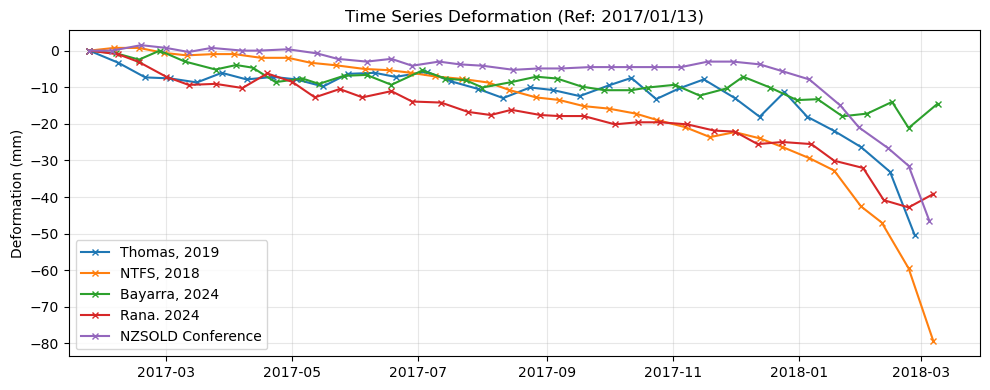

In [4]:
df = pd.read_excel('ANalysis FILES/Deformation.xlsx', sheet_name='FINAL', header=None)

labels = ["Thomas, 2019", "NTFS, 2018", "Bayarra, 2024", "Rana. 2024", "NZSOLD Conference"]
ref_date = pd.to_datetime('2017/01/13')
plt.figure(figsize=(10, 4))

for i, start_col in enumerate(range(0, 15, 3)):
    data = df.iloc[2:, [start_col, start_col + 1]].dropna()
    dates = pd.to_datetime(data.iloc[:, 0], dayfirst=True, errors='coerce')
    values = pd.to_numeric(data.iloc[:, 1], errors='coerce')
    mask = dates >= ref_date
    plt.plot(dates[mask], values[mask], label=labels[i],marker='x', markersize=5)

plt.title('Time Series Deformation (Ref: 2017/01/13)')
plt.ylabel('Deformation (mm)')
plt.xlim(left=ref_date) # Forces the plot to start at reference date
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

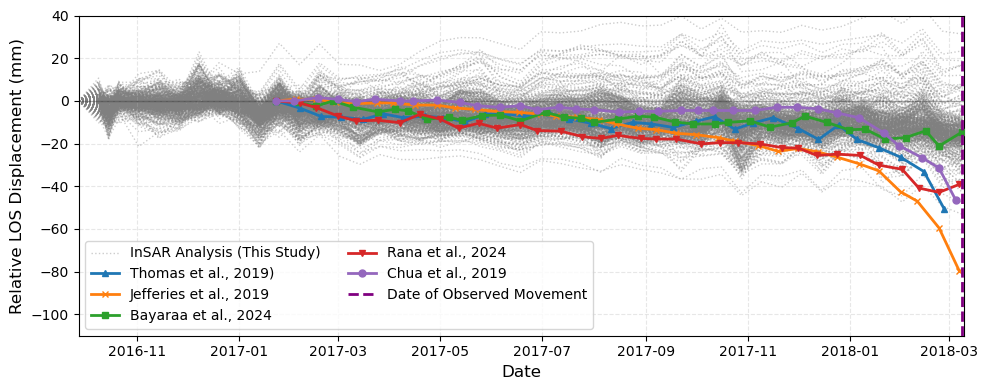

In [5]:
def coord_to_index(h5_file, lats, lons):
    with h5py.File(h5_file, 'r') as f:
        attrs = f.attrs
        x_step, y_step = float(attrs['X_STEP']), float(attrs['Y_STEP'])
        x_first, y_first = float(attrs['X_FIRST']), float(attrs['Y_FIRST'])
        col_indices = [int(round((lon - x_first) / x_step)) for lon in lons]
        row_indices = [int(round((lat - y_first) / y_step)) for lat in lats]
        return row_indices, col_indices

def get_dates(h5_file):   
    with h5py.File(h5_file, 'r') as f:  
        date_list_str = f['date'][:]            
        return [datetime.datetime.strptime(d.decode('utf-8'), '%Y%m%d') for d in date_list_str]
        
def extract_timeseries(h5_file, rows, cols):    
    with h5py.File(h5_file, 'r') as f:       
        ds_name = 'timeseries' if 'timeseries' in f.keys() else list(f.keys())[0]          
        data = f[ds_name] 
        return [data[:, r, c] for r, c in zip(rows, cols)]

def calculate_los(row, prism_prefix, theta, alpha):
    """Projects 3D prism vectors into 1D InSAR Line of Sight (LOS)."""
    d_ver, d_perp, d_par = row[f'{prism_prefix} Ver'], row[f'{prism_prefix} Perp'], row[f'{prism_prefix} Par']
    return (d_ver * np.cos(theta) - d_par * np.sin(theta) * np.cos(alpha) + d_perp * np.sin(theta) * np.sin(alpha))

REF_DATE = pd.to_datetime('2016-09-27')
FAILURE_DATE = pd.to_datetime('2018-03-09')

target_lats = [p['Lat'] for p in ranked] + [-33.5075]
target_lons = [p['Lon'] for p in ranked] + [149.009]

FAILURE_IDX = len(target_lats) - 1
REF_INDICES = list(range(len(ranked)))

dates_insar = get_dates(h5_path)
rows, cols = coord_to_index(h5_path, target_lats, target_lons)
ts_data = extract_timeseries(h5_path, rows, cols)
failure_ts = ts_data[FAILURE_IDX]

plt.figure(figsize=(10, 4))

insar_dates_np = np.array(dates_insar, dtype='datetime64[ns]')
ref_date_np = np.datetime64(REF_DATE)
insar_ref_idx = np.argmin(np.abs(insar_dates_np - ref_date_np))

for i in REF_INDICES:
    rel_disp_mm = (failure_ts - ts_data[i]) * 1000
    rel_disp_mm -= rel_disp_mm[insar_ref_idx] # Aligned to Ref Date at 0mm
    
    mask = insar_dates_np >= ref_date_np
    plt.plot(insar_dates_np[mask], rel_disp_mm[mask], color='grey', 
             linestyle=':', linewidth=1, alpha=0.4, zorder=1,
             label="InSAR Analysis (This Study)" if i == 0 else "")

#LITERATURE DATA 
colors_lit = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'] # Different Colors
lit_labels = ["Thomas et al., 2019)", "Jefferies et al., 2019", "Bayaraa et al., 2024", "Rana et al., 2024", "Chua et al., 2019"]
lit_markers = ['^', 'x', 's', 'v', 'o']

df_lit = pd.read_excel('ANalysis FILES/Deformation.xlsx', sheet_name='FINAL', header=None)

for i, start_col in enumerate(range(0, 15, 3)):
    data = df_lit.iloc[2:, [start_col, start_col + 1]].dropna()
    l_dates = pd.to_datetime(data.iloc[:, 0], dayfirst=True)
    l_vals = pd.to_numeric(data.iloc[:, 1])
    
    mask = l_dates >= REF_DATE
    plt.plot(l_dates[mask], l_vals[mask], 
             label=lit_labels[i], 
             marker=lit_markers[i], 
             markersize=5, 
             color=colors_lit[i], # Use unique color
             linewidth=2,       # Slightly thicker for clarity
             zorder=3)

#  FORMATTING
plt.axvline(FAILURE_DATE, color='purple', linestyle='--', linewidth=2, label='Date of Observed Movement', zorder=5)
plt.axhline(0, color='black', linewidth=1, alpha=0.3)
plt.ylabel("Relative LOS Displacement (mm)", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.xlim(left=REF_DATE, right=datetime.datetime(2018, 3, 10))
plt.ylim(-110, 40)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='lower left', fontsize=10, ncol=2, frameon=True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()